# **AICE Associate 자격인증 <font color=red>샘플문항</font>**
### **내비게이션 주행데이터를 이용한 <span style="color:darkgreen">도착시각</span> 예측 문제**
- 내비게이션 주행데이터를 읽어들여 데이터를 분석 및 전처리한 후 머신러닝과 딥러닝으로 도착시각을 예측하고 결과를 분석하세요.
---

#### **<span style="color:red">[유의사항]</span>**
- <span style="color:darkgreen">각 문항의 답안코드는 반드시 *'# 여기에 답안코드를 작성하세요'* 로 표시된 cell에 작성해야 합니다.</span>
- <span style="color:darkgreen">제공된 시험문항 cell을 삭제하거나 답안 위치가 아닌 다른 cell에 답안코드를 작성 시 채점되지 않습니다. </span>
- 시험 중에는 상단의 '임시저장' 버튼을 클릭하여 저장을 해주시고, 답안 제출시에는 '최종제출' 버튼을 클릭해주시기 바랍니다.
- 반드시 문제에 제시된 가이드를 읽고 답안 작성하세요.
- 문제에 변수명이 제시된 경우 반드시 해당 변수명을 사용하세요.
- 자격인증 문제에 제공된 데이터는 제 3자에게 공유하거나 개인적인 용도로 사용하는 등 외부로 유출할 수 없으며 유출로 인한 책임은 응시자 본인에게 있습니다.
- <font color=blue>**오픈북 허용사이트에서만 참고 가능하며 그외 사이트 참고시 부정행위로 간주될수 있습니다.**</font>
---

**[ 데이터 컬럼 설명 (데이터 파일명: signal_data.csv) ]**

- RID                 : 경로ID
- Time_Departure      : 출발시각
- Time_Arrival        : 도착시각
- Distance            : 이동 거리, 단위 (m)
- Time_Driving        : 실주행시간(초)
- Speed_Per_Hour      : 평균시속
- Address1            : 주소1
- Address2            : 주소2
- Weekday             : Time_Departure(출발시각)의 요일
- Hour                : Time_Departure(출발시각)의 시각
- Day                 : Time_Departure(출발시각)의 날짜
- Signaltype : 경로의 신호등 갯수

<br>
<br>

### **1. Pandas는 데이터 분석을 위해 널리 사용되는 파이썬 라이브러리입니다.**
### **Pandas를 사용할 수 있도록 별칭(alias)을 pd로 해서 불러오세요.**
---

In [1]:
# 여기에 답안코드를 작성하세요.
import pandas as pd

<br>
<br>

### **2. AI 모델링을 위해 분석 및 처리할 데이터 파일을 읽어오려고 합니다.**
### **Pandas 함수로 데이터 파일을 읽어 데이터프레임 변수 df에 할당하는 코드를 작성하세요.**

* **
- 데이터프레임 변수명 : df
- 데이터 파일명 : signal_data.csv (csv 파일은 본 문제/답안지와 동일한 경로에 있습니다.)
---

In [18]:
# 여기에 답안코드를 작성하세요.
df = pd.read_csv('./data/signal_data.csv')

<br>
<br>

> **<span style="color:red">다음 문항을 풀기 전에 </span>아래 코드를 실행하세요.**
<small>(해결되지 않는다면 아래 Colab 한글 깨짐 현상 해결법 참고)<br>https://developnote.tistory.com/165#google_vignette </small>

In [3]:
# (Jupyter) 시각화 한글폰트 설정을 위해 아래 코드를 실행하세요.
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='Malgun Gothic')
sns.set(font="Malgun Gothic",#"NanumGothicCoding",
        rc={"axes.unicode_minus":False}, # 마이너스 부호 깨짐 현상 해결
        style='darkgrid')

<br>
<br>

### **3. Address1(주소1)에 대한 분포도를 알아보려고 합니다.**
### **Address1(주소1)에 대해 countplot을 그리는 코드와 답안을 작성하세요.**

* **
- 대상 데이터프레임 : df
- Seaborn을 활용하세요.
- 첫번째, Address1(주소1)에 대해서 분포를 보여주는 countplot 그래프 그리세요.
- 두번째, Address1(주소1)에 지역명이 없는 '-' 에 해당되는 row(행)을 삭제하세요.
- 출력된 그래프를 보고 해석한 것으로 옳지 않은 선택지를 아래에서 골라 **'답안03'** 변수에 저장하세요.(예. 답안03 = 4)
  1. Countplot 그래프에서 Address1(주소1) 분포를 확인시 '경기도' 분포가 제일 크다.
  2. Address1(주소1) 분포를 보면 '인천광역시' 보다 '서울특별시'가 더 크다.
  3. 지역명이 없는 '-' 에 해당되는 row(행)가 2개 있다.
---

Address1
경기도      6014
서울특별시    3956
인천광역시      27
-           3
Name: count, dtype: int64

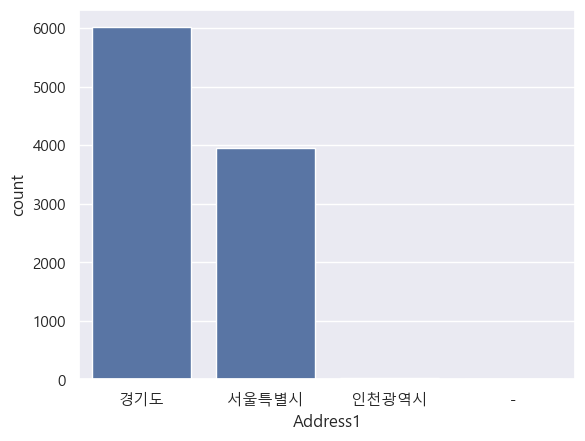

In [19]:
# 여기에 답안코드를 작성하세요.
import seaborn as sns
sns.countplot(df, x='Address1')
display(df['Address1'].value_counts())
df = df[df['Address1'] != '-']
답안03 = 3


<br>
<br>

### **4. 컬럼들간의 상관관계를 파악하고자 합니다.**
### **가이드에 따라 컬럼들의 상관관계를 구하는 코드의 빈칸을 채우고 답안을 작성하세요.**
* **
- 대상 데이터프레임: df
- 특정 컬럼에 대한 상관관계를 구하는 코드는 주어집니다.
- 코드의 빈칸 '< blank1 >' 을 채우고, 반드시 코드를 실행하세요.
- 코드의 빈칸 '< blank1 >' 값을 '답안04_1' 변수에 저장하세요. 예) 답안04_1 = '함수명'
- 출력된 상관관계 테이블을 보고 이동 거리(Distance) 컬럼과 상관관계가 가장 높은 컬럼을 '답안04_2' 변수에 저장하세요. 예) 답안04_2 = 'Distance'
---

In [14]:
# 여기에 질문답안과 답안코드를 작성하세요. 그리고  '< blank1 >'를 채우고 코드를 실행하세요.
column_list = ['Distance', 'Time_Driving', 'Speed_Per_Hour', 'Weekday', 'Hour', 'Day', 'Signaltype']
display(df[ column_list  ].corr())
답안04_1 = 'corr()'
답안04_2 = 'Time_Driving'

,Distance,Time_Driving,Speed_Per_Hour,Weekday,Hour,Day,Signaltype
Distance,1.000000,0.540645,0.334054,-0.004824,-0.033400,0.014442,0.232580
Time_Driving,0.540645,1.000000,-0.433475,-0.007138,0.011680,0.002867,0.542863
Speed_Per_Hour,0.334054,-0.433475,1.000000,0.011897,-0.048228,-0.007199,-0.391318
Weekday,-0.004824,-0.007138,0.011897,1.000000,-0.061033,0.127337,-0.004085
Hour,-0.033400,0.011680,-0.048228,-0.061033,1.000000,-0.063664,0.003296
Day,0.014442,0.002867,-0.007199,0.127337,-0.063664,1.000000,-0.005974
Signaltype,0.232580,0.542863,-0.391318,-0.004085,0.003296,-0.005974,1.000000


<br>
<br>

### **5. 실주행시간과 평균시속의 분포를 같이 확인하려고 합니다.**
### **Time_Driving(실주행시간)과 Speed_Per_Hour(평균시속)을 jointplot그래프로 만드세요.**

* **
- 대상 데이터프레임 : df
- Seaborn을 활용하세요.
- X축에는 Time_Driving(실주행시간)을 표시하고 Y축에는 Speed_Per_Hour(평균시속)을 표시하세요.
---

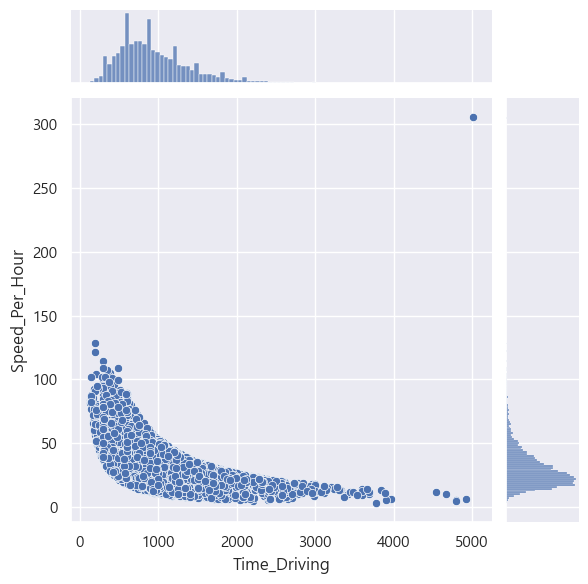

In [ ]:
# 여기에 답안코드를 작성하세요.
sns.jointplot(df, x='Time_Driving', y='Speed_Per_Hour')

<br>
<br>

### **6. 위의 jointplot 그래프에서 시속 300이 넘는 이상치를 발견할수 있습니다.**
### **가이드에 따라서 전처리를 수행하고 저장하세요.**
* **
- 대상 데이터프레임 : df
- jointplot 그래프를 보고 시속 300 초과하는 이상치를 찾아 해당 행(Row)을 삭제하세요.
- 불필요한 'RID' 컬럼을 삭제 하세요.
- 전처리 반영 후에 데이터프레임 변수명 df_temp 에 저장하세요.
---

In [21]:
# 여기에 답안코드를 작성하세요.
df_temp = df[df['Speed_Per_Hour'] <= 300]
df_temp = df_temp.drop(columns=['RID'])

<br>
<br>

<br>
<br>

### **7. 모델링 성능을 제대로 얻기 위해서 결측치 처리는 필수입니다.**
### **아래 가이드를 따라 결측치 처리하세요.**
* **
- 대상 데이터프레임 : df_temp
- 각 컬럼의 결측치 개수를 확인하는 코드를 작성하세요.
- 결측치가 있는 행(row)를 삭제 하세요.
- 전처리 반영된 결과를 데이터프레임 변수명 df_na 에 저장하세요.
- 결측치 개수를 '답안07' 변수에 저장하세요.(예. 답안07 = 5)
---

In [28]:
# 여기에 답안코드를 작성하세요.
display(df_temp.isnull().sum())
df_na = df_temp.dropna()
답안07 = 2

Time_Departure    0
Time_Arrival      0
Distance          2
Time_Driving      0
Speed_Per_Hour    0
Address1          0
Address2          0
Weekday           0
Hour              0
Day               0
Signaltype        0
dtype: int64

<br>
<br>

<br>
<br>

### **8. 모델링 성능을 제대로 얻기 위해서 불필요한 변수는 삭제해야 합니다.**
### **아래 가이드를 따라 불필요 데이터를 삭제 처리하세요.**
* **
- 대상 데이터프레임 : df_na
- 'Time_Departure', 'Time_Arrival' 2개 컬럼을 삭제하세요.
- 전처리 반영된 결과를 새로운 데이터프레임 변수명 df_del 에 저장하세요.
---

In [30]:
# 여기에 답안코드를 작성하세요.
columns = ['Time_Departure', 'Time_Arrival']

df_del = df_na.drop(columns=columns)

<br>
<br>

### **9. 원-핫 인코딩(One-hot encoding)은 범주형 변수를 1과 0의 이진형 벡터로 변환하기 위하여 사용하는 방법입니다.**
### **원-핫 인코딩으로 아래 조건에 해당하는 컬럼 데이터를 변환하세요.**
* **
- 대상 데이터프레임 : df_del
- 원-핫 인코딩 대상 : object 타입의 전체 컬럼
- 활용 함수: Pandas의 get_dummies
- 해당 전처리가 반영된 결과를 데이터프레임 변수 df_preset에 저장해 주세요.
---

In [32]:
# 여기에 답안코드를 작성하세요.
df_preset = pd.get_dummies(df_del)

<br>
<br>

### **10. 훈련과 검증 각각에 사용할 데이터셋을 분리하려고 합니다.**
### **Time_Driving(실주행시간) 컬럼을 label값 y로, 나머지 컬럼을 feature값 X로 할당한 후 훈련데이터셋과 검증데이터셋으로 분리하세요(대소문자 유의).**
### **추가로,  가이드 따라서 훈련데이터셋과 검증데이터셋에 스케일링을 수행하세요.**
* **
- 대상 데이터프레임 : df_preset
- 훈련과 검증 데이터셋 분리
  - 훈련 데이터셋 label : y_train, 훈련 데이터셋 Feature: X_train
  - 검증 데이터셋 label : y_valid, 검증 데이터셋 Feature: X_valid
  - 훈련 데이터셋과 검증데이터셋 비율은 80:20
  - random_state : 42
  - Scikit-learn의 train_test_split 함수를 활용하세요.
- RobustScaler 스케일링 수행
  - sklearn.preprocessing의 RobustScaler 함수 사용
  - 훈련데이터셋의 Feature는 RobustScaler의 fit_transform 함수를 활용하여 X_train 변수로 할당
  - 검증데이터셋의 Feature는 RobustScaler의 transform 함수를 활용하여 X_valid 변수로 할당
---

In [ ]:
# 여기에 답안코드를 작성하세요.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler


X = df_preset.drop(columns=['Time_Driving'])
y = df_preset['Time_Driving']
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

<br>
<br>

###  **11. Time_Driving(실주행시간)을 예측하는 머신러닝 모델을 만들려고 합니다.**
###  **의사결정나무(decision tree)와 랜덤포레스트(RandomForest)는 여러 가지 규칙을 순차적으로 적용하면서**
### **독립 변수 공간을 분할하는 모형으로 분류(classification)와 회귀 분석(regression)에 모두 사용될 수 있습니다.**
###  **아래 가이드에 따라 의사결정나무(decision tree)와 랜덤포레스트(RandomForest) 모델 만들고 학습을 진행하세요.**

* **
- 의사결정나무(decision tree)
  - 트리의 최대 깊이 : 5로 설정
  - 노드를 분할하기 위한 최소한의 샘플 데이터수(min_samples_split) : 3로 설정
  - random_state : 120로 설정
  - 의사결정나무(decision tree) 모델을 dt 변수에 저장해 주세요.
- 랜덤포레스트(RandomForest)
  - 트리의 최대 깊이 : 5로 설정
  - 노드를 분할하기 위한 최소한의 샘플 데이터수(min_samples_split) : 3로 설정
  - random_state : 120로 설정
  - 랜덤포레스트(RandomForest) 모델을 rf 변수에 저장해 주세요.
- 위의 2개의 모델에 대해 fit을 활용해 모델을 학습해 주세요. 학습 시 훈련데이터 셋을 활용해 주세요.
---

In [37]:
# 여기에 답안코드를 작성하세요.
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

dt = DecisionTreeRegressor(max_depth=5, min_samples_split=3, random_state=120)
rf = RandomForestRegressor(max_depth=5, min_samples_split=3, random_state=120)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, min_samples_split=3, random_state=120)

<br>
<br>

### **12. 위 의사결정나무(decision tree)와 랜덤포레스트(RandomForest) 모델의 성능을 평가하려고 합니다.**
### **아래 가이드에 따라 예측 결과의 mae(Mean Absolute Error)를 구하고 평가하세요.**
* **
- 성능 평가는 검증 데이터셋을 활용하세요.
- 11번 문제에서 만든 의사결정나무(decision tree) 모델로 y값을 예측(predict)하여 y_pred_dt에 저장하세요.
- 검증 정답(y_valid)과 예측값(y_pred_dt)의 mae(Mean Absolute Error)를 구하고 dt_mae 변수에 저장하세요.
- 11번 문제에서 만든 랜덤포레스트(RandomForest) 모델로 y값을 예측(predict)하여 y_pred_rf에 저장하세요.
- 검증 정답(y_valid)과 예측값(y_pred_rf)의 mae(Mean Absolute Error)를 구하고 rf_mae 변수에 저장하세요.
- 2개의 모델에 대한 mae 성능평가 결과을 확인하여 성능좋은 모델 이름을 '답안12' 변수에 저장하세요.
  - 예) 답안12 = 'decisiontree' 혹은 답안12 = 'randomforest'
---

In [39]:
# 여기에 답안코드를 작성하세요.
from sklearn.metrics import mean_absolute_error

y_pred_dt = dt.predict(X_valid)
dt_mae = mean_absolute_error(y_valid, y_pred_dt)

y_pred_rf = rf.predict(X_valid)
rf_mae = mean_absolute_error(y_valid, y_pred_rf)
print(f"dt_mae: {dt_mae}\nrf_mae: {rf_mae}")
답안12 = 'randomforest'

dt_mae: 108.66520360619405
rf_mae: 66.49137400827676


<br>
<br>

> **<span style="color:red">다음 문항을 풀기 전에 </span>아래 코드를 실행하세요.**
>

In [40]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(1)

<br>
<br>

### **13. Time_Driving(실주행시간)을 예측하는 딥러닝 모델을 만들려고 합니다.**
### **아래 토폴로지 그림과 가이드에 따라 모델링하고 학습을 진행하는 코드를 작성하세요.**
* **
- Tensorflow framework를 사용하고 하단의 토폴로지 그림과 동일한 딥러닝 모델을 구현하세요.
- 히든 레이어의 activation 함수는 'selu'를 사용하고 , 마지막 아웃풋 레이어의 activation 함수는 'linear'를 사용하세요.
- EarlyStopping 콜백으로 9번 epoch 동안 모니터링 지표(val_loss)가 향상되지 않을 때 훈련을 중지하도록 설정하고 estop 변수에 저장하세요.
- optimizer는 adam, metrics는 mse, loss는 mean_squared_error로 설정하여 모델 컴파일을 설정하세요.
- 다음 조건에 따라 모델을 학습하고 학습정보는 history 변수에 저장해 주세요.
  - batch_size : 128
  - epoch : 50
- 안내된 내용 외 별도의 파라미터를 입력하지 마시기 바랍니다.
---



<p align="center">
<img src="data/sample_dnn_v3.png">
</p>

In [52]:
# 여기에 답안코드를 작성하세요.
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.backend import clear_session

clear_session()

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='selu'),
    Dropout(0.1),
    Dense(32, activation='selu'),
    Dense(16, activation='selu'),
    Dense(1, activation='linear')
])

estop = EarlyStopping(monitor='val_loss', patience=9)

model.compile(optimizer=Adam(), metrics=['mse'], loss='mean_squared_error')

history = model.fit(X_train, y_train, validation_data=(X_valid, y_valid), batch_size=128, epochs=50).history



Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1181772.2500 - mse: 1181772.2500 - val_loss: 1083766.0000 - val_mse: 1083766.0000
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1055494.3750 - mse: 1055494.3750 - val_loss: 837410.8750 - val_mse: 837410.8750
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 617222.8125 - mse: 617222.8125 - val_loss: 286691.5938 - val_mse: 286691.5938
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 187608.4844 - mse: 187608.4844 - val_loss: 117008.7656 - val_mse: 117008.7656
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 119336.3125 - mse: 119336.3125 - val_loss: 88507.3047 - val_mse: 88507.3047
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 94013.3203 - mse: 94013.3203 - val_loss: 68383.6484 - val_mse: 68383.6484
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 76703.6016 - mse: 76703.6016 - val_loss: 54629.7383 - val_mse: 54629.7383
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step -

<br>
<br>

### **14. 위 딥러닝 모델의 성능을 평가하려고 합니다.**
### **Matplotlib 라이브러리 활용해서 학습 mse와 검증 mse를 그래프로 표시하세요.**
* **
- 1개의 그래프에 학습 mse과 검증 mse 2가지를 모두 표시하세요.
- 위 2가지 각각의 범례를 'mse', 'val_mse'로 표시하세요.
- 그래프의 타이틀은 'Model MSE'로 표시하세요.
- X축에는 'Epochs'라고 표시하고 Y축에는 'MSE'라고 표시하세요.
---


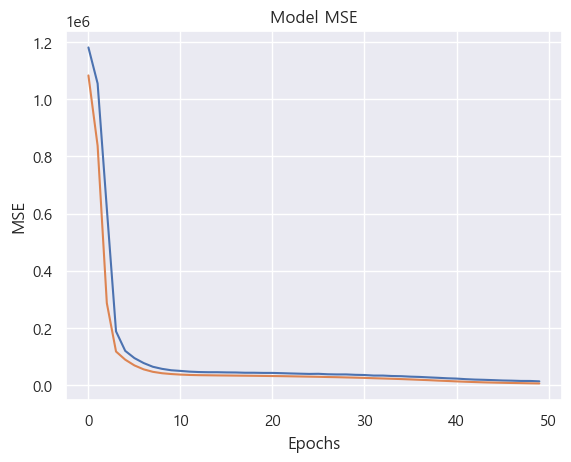

In [ ]:
# 여기에 답안코드를 작성하세요.
import matplotlib.pyplot as plt

plt.plot(history['mse'])
plt.plot(history['val_mse'])
plt.title('Model MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.show()


<br>
<br>

### **1번부터 14번까지 모든 문제를 풀었습니다. 수고하셨습니다.**
### **'최종제출 및 종료'를 클릭하셔서 답안을 제출해 주시기 바랍니다.**